In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

### customerID column does not seem relevant. So we drop this column

In [7]:
df.drop('customerID', axis=1, inplace=True)

#### Convert Total Charges column to numeric datatype and then drop null values. It is the only column with empty data

In [8]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')

In [9]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df.dropna( inplace=True)

#### check for duplicates

In [11]:
df.duplicated().sum()

np.int64(22)

In [12]:
df.drop_duplicates(keep='first', inplace=True)

In [13]:
df.shape

(7010, 20)

## EDA

### Let us look at the distribution of numerical features

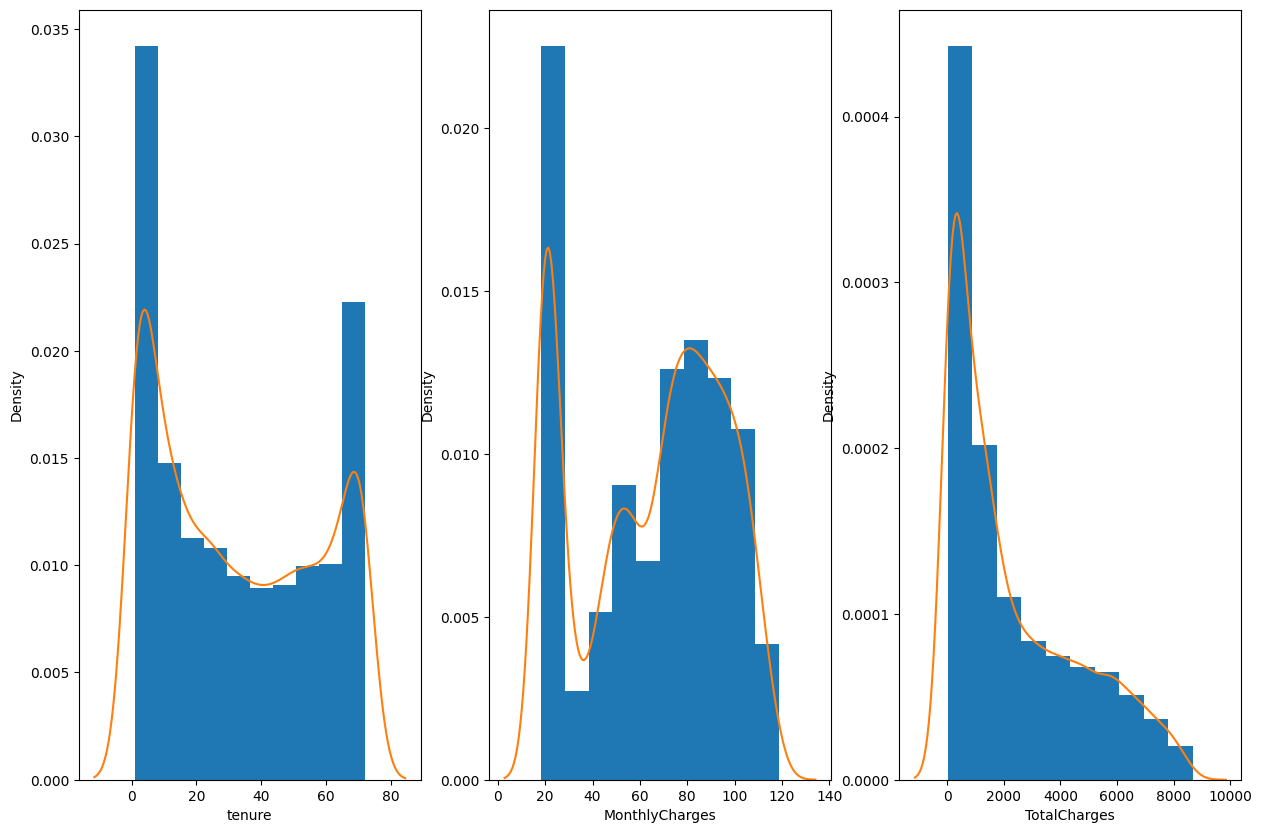

In [14]:
numer_col = [col for col in df.columns if df[col].dtype !='str']
numer_col.remove('SeniorCitizen')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,10))

for i, ax in enumerate(axes):
    ax.hist(df[numer_col[i]], density=True)
    sns.kdeplot(df[numer_col[i]], ax=ax)

plt.show()

#### Let us look at countplots of categorical features

In [15]:
cat_feat = [col for col in df.columns if (df[col].dtype == 'str')&(col!='Churn')]
cat_feat.append('SeniorCitizen')

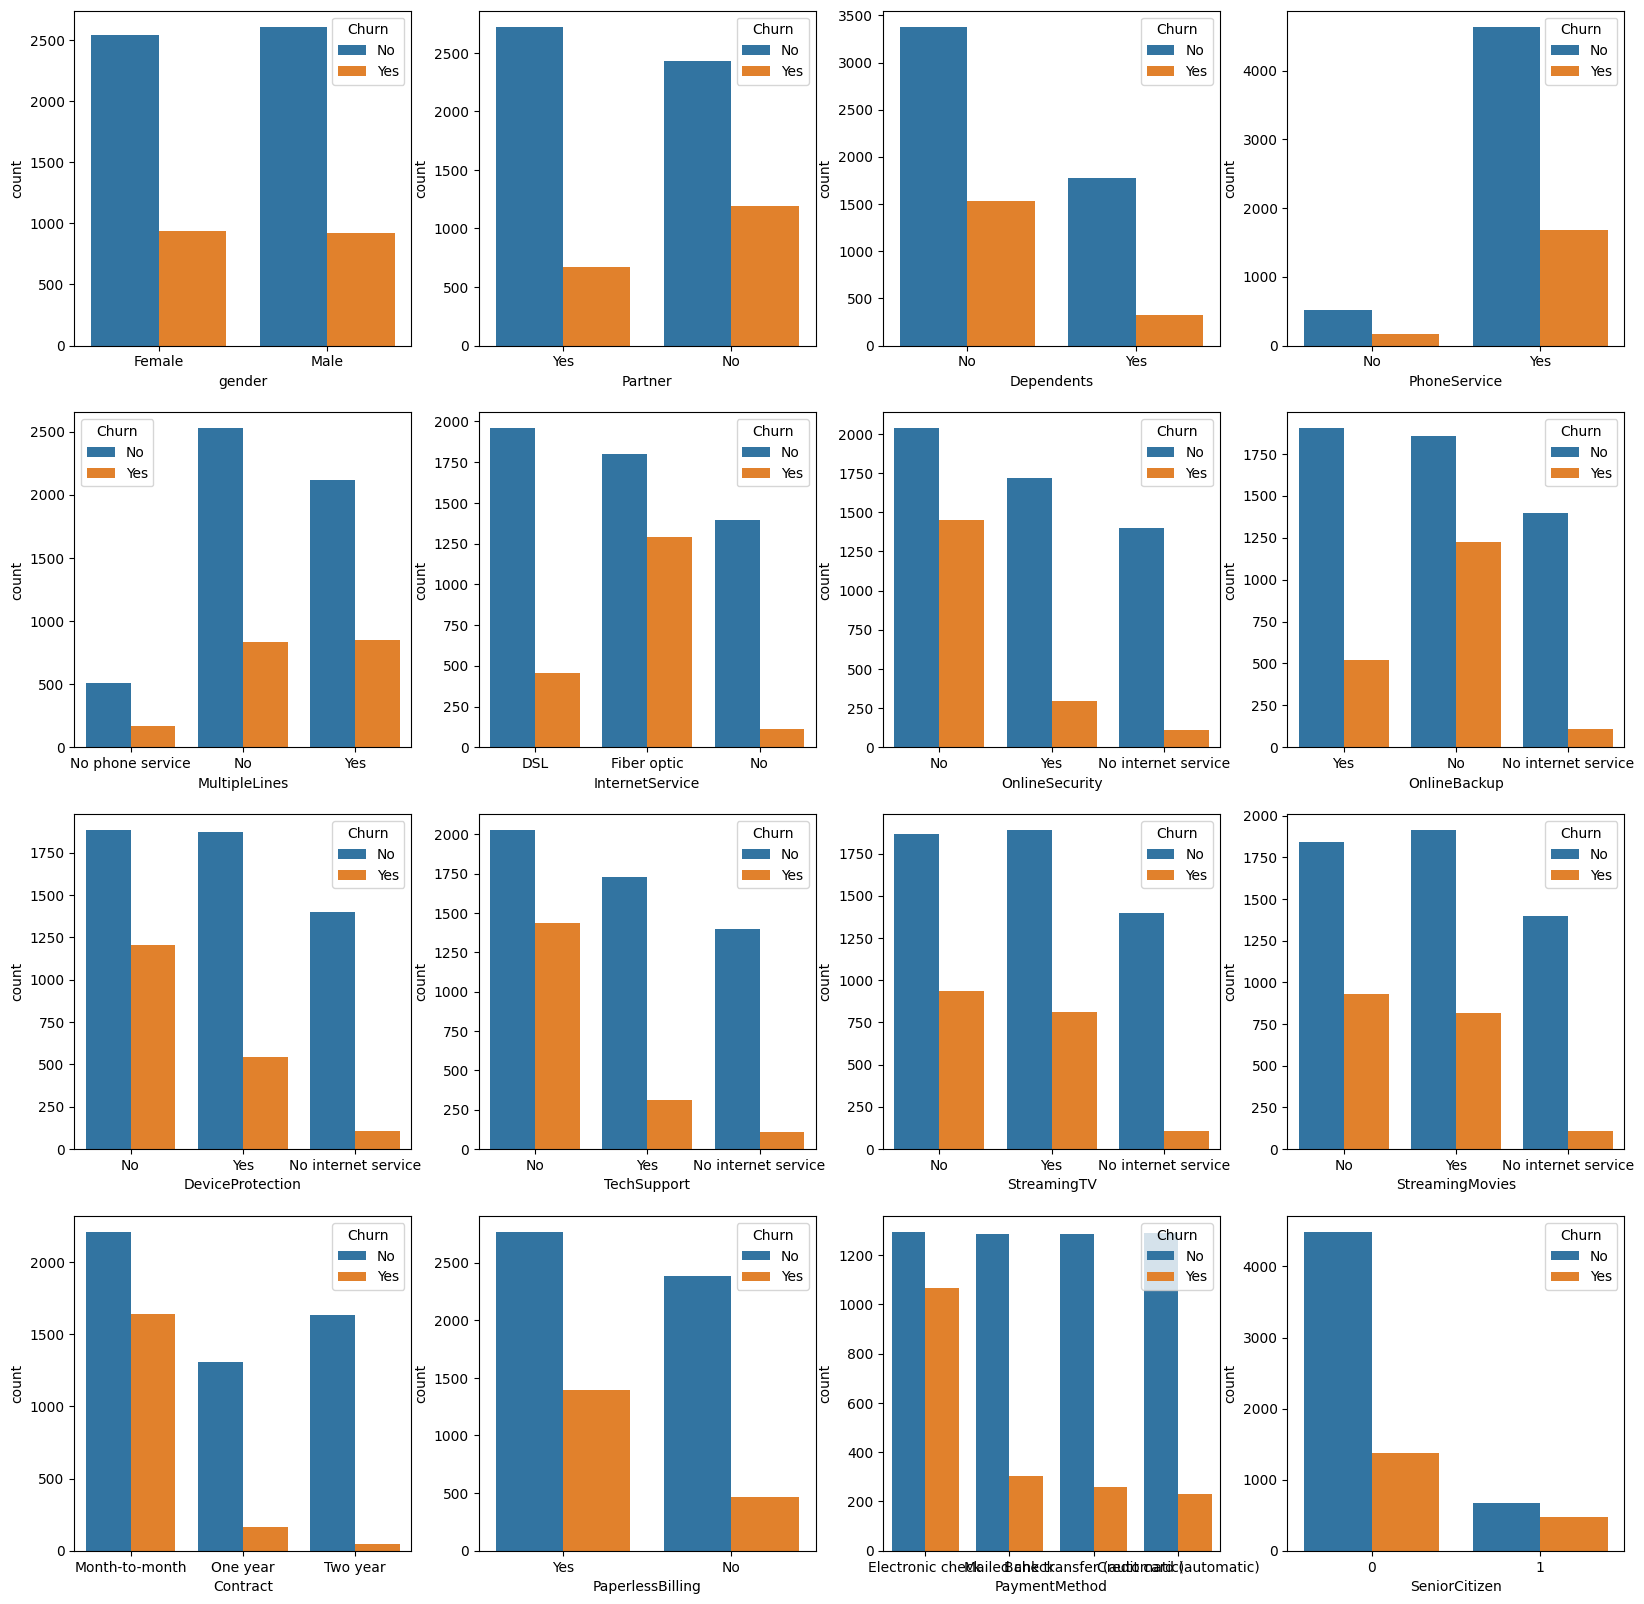

In [16]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20,20))

for row_idx, row_ax in enumerate(axes):
    for col_idx, col_ax in enumerate(row_ax):
        sns.countplot(x=cat_feat[row_idx*4 + col_idx], data=df, ax=col_ax, hue='Churn')

#### Let us now look at heatmap of numerical columns

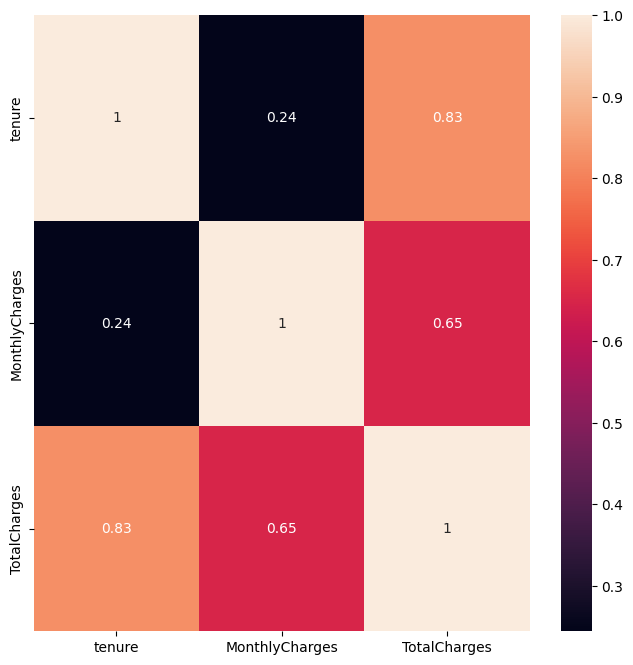

In [17]:
df_num = df[numer_col]

fig, ax = plt.subplots(figsize=(8,8))

sns.heatmap(df_num.corr(), annot=True, ax=ax)
plt.show()

#### We see that tenure and TotalCharges are highly correlated which is expected because longer customer is with the company higher should be the charges.

## Label Encoding for binary features and one-hot for other categorical features

In [18]:
bin_feat = [col for col in df.columns if (df[col].nunique()==2)]
bin_feat.remove('SeniorCitizen')

In [19]:
# Label encoding for binary features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in bin_feat:
    df[col] = le.fit_transform(df[col])

In [20]:
# One-hot encoding for other categorical features
df = pd.get_dummies(df, drop_first=True)


In [21]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


#### Let us do ANOVA F-test to see how average value of the features varies between the two classes.
#### This is same as two-sample t-test since churn(target column) is binary

Test is used to measure whether the average value of each encoded feature differs significantly between churned and non-churned customers. For one-hot encoded categorical features, the mean represents the proportion of customers belonging to that category.

In [22]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [23]:
from sklearn.feature_selection import f_classif
[f_stat, p_value] = f_classif(X, y)

In [24]:
f_test_df = pd.DataFrame({
    'Features':X.columns,
    'F statistic': f_stat,
    'p value': p_value
})

In [25]:
f_test_df.sort_values('p value')

,Features,F statistic,p value
4,tenure,999.755231,3.093127e-205
11,InternetService_Fiber optic,732.439926,1.649750e-153
26,Contract_Two year,700.104043,3.952082e-147
28,PaymentMethod_Electronic check,698.590424,7.872389e-147
12,InternetService_No,385.063472,1.661638e-83
17,DeviceProtection_No internet service,385.063472,1.661638e-83
15,OnlineBackup_No internet service,385.063472,1.661638e-83
13,OnlineSecurity_No internet service,385.063472,1.661638e-83
19,TechSupport_No internet service,385.063472,1.661638e-83
23,StreamingMovies_No internet service,385.063472,1.661638e-83


#### Though we will not use above data for feature selection but extremely small p values for many of the features suggest that average value of these features in the two classes are very different. It suggests that these features will be useful in prediction

#### Export the cleaned and processed data into a csv file which can be used for further analysis

In [26]:
df.to_csv('Telco_Customer_Churn_clean.csv', index= False)

#### Import clean file for SQL analysis

In [27]:
df_sql = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_sql['TotalCharges'] = pd.to_numeric(df_sql['TotalCharges'], errors='coerce')
df_sql = df_sql.dropna()
df_sql = df_sql.drop_duplicates()

df_sql.to_csv('Telco_Customer_Churn_SQL_clean.csv', index=False)